In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
import numpy as np

In [25]:
housing_data=pd.read_csv("Bengaluru_House_Data2.csv")
housing_data

,area_type,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07
1,Plot Area,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00
2,Built-up Area,Uttarahalli,3 BHK,1440,2.0,3.0,62.00
3,Super built-up Area,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00
4,Super built-up Area,Kothanur,2 BHK,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...
13315,Built-up Area,Whitefield,5 Bedroom,3453,4.0,0.0,231.00
13316,Super built-up Area,Richards Town,4 BHK,3600,5.0,NaN,400.00
13317,Built-up Area,Raja Rajeshwari Nagar,2 BHK,1141,2.0,1.0,60.00
13318,Super built-up Area,Padmanabhanagar,4 BHK,4689,4.0,1.0,488.00


In [26]:
imputer = SimpleImputer(strategy="median")
housing_num = housing_data.select_dtypes(include=[np.number])
imputer.fit(housing_num)

SimpleImputer(strategy='median')

In [29]:
x = imputer.transform(housing_num)
x

array([[  2.  ,   1.  ,  39.07],
       [  5.  ,   3.  , 120.  ],
       [  2.  ,   3.  ,  62.  ],
       ...,
       [  2.  ,   1.  ,  60.  ],
       [  4.  ,   1.  , 488.  ],
       [  1.  ,   1.  ,  17.  ]])

In [32]:
# Convert price from lakhs to actual value
housing_data["price"] = housing_data["price"] * 100000

# Select only numerical columns
housing_num = housing_data.select_dtypes(include=[np.number])

# Create and apply median imputer
imputer = SimpleImputer(strategy="median")
housing_num_imputed = imputer.fit_transform(housing_num)

# Convert back to DataFrame
housing_num_imputed = pd.DataFrame(
    housing_num_imputed,
    columns=housing_num.columns
)
housing_num_imputed

,bath,balcony,price
0,2.0,1.0,3907000.0
1,5.0,3.0,12000000.0
2,2.0,3.0,6200000.0
3,3.0,1.0,9500000.0
4,2.0,1.0,5100000.0
...,...,...,...
13315,4.0,0.0,23100000.0
13316,5.0,2.0,40000000.0
13317,2.0,1.0,6000000.0
13318,4.0,1.0,48800000.0


In [33]:
housing_cat = housing_data.select_dtypes(exclude=[np.number])

# Create imputer for categorical data
cat_imputer = SimpleImputer(strategy="most_frequent")

# Apply imputation
housing_cat_imputed = cat_imputer.fit_transform(housing_cat)

# Convert back to DataFrame
housing_cat_imputed = pd.DataFrame(
    housing_cat_imputed,
    columns=housing_cat.columns
)
housing_cat_imputed

,area_type,location,size,total_sqft
0,Super built-up Area,Electronic City Phase II,2 BHK,1056
1,Plot Area,Chikka Tirupathi,4 Bedroom,2600
2,Built-up Area,Uttarahalli,3 BHK,1440
3,Super built-up Area,Lingadheeranahalli,3 BHK,1521
4,Super built-up Area,Kothanur,2 BHK,1200
...,...,...,...,...
13315,Built-up Area,Whitefield,5 Bedroom,3453
13316,Super built-up Area,Richards Town,4 BHK,3600
13317,Built-up Area,Raja Rajeshwari Nagar,2 BHK,1141
13318,Super built-up Area,Padmanabhanagar,4 BHK,4689


In [34]:
# Combine imputed numerical and categorical data
housing_data_cleaned = pd.concat(
    [housing_num_imputed, housing_cat_imputed],
    axis=1
)

# Optional: reorder columns to match original dataset
housing_data_cleaned = housing_data_cleaned[housing_data.columns]
housing_data_cleaned

,area_type,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,Electronic City Phase II,2 BHK,1056,2.0,1.0,3907000.0
1,Plot Area,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,12000000.0
2,Built-up Area,Uttarahalli,3 BHK,1440,2.0,3.0,6200000.0
3,Super built-up Area,Lingadheeranahalli,3 BHK,1521,3.0,1.0,9500000.0
4,Super built-up Area,Kothanur,2 BHK,1200,2.0,1.0,5100000.0
...,...,...,...,...,...,...,...
13315,Built-up Area,Whitefield,5 Bedroom,3453,4.0,0.0,23100000.0
13316,Super built-up Area,Richards Town,4 BHK,3600,5.0,2.0,40000000.0
13317,Built-up Area,Raja Rajeshwari Nagar,2 BHK,1141,2.0,1.0,6000000.0
13318,Super built-up Area,Padmanabhanagar,4 BHK,4689,4.0,1.0,48800000.0


In [35]:
# Check remaining null values
housing_data_cleaned.isnull().sum()

area_type     0
location      0
size          0
total_sqft    0
bath          0
balcony       0
price         0
dtype: int64

<h1>Following is the correct step by step procedure</h1>

In [36]:
#import statements

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [36]:
#read CSV
housing_data=pd.read_csv("Bengaluru_House_Data2.csv")
housing_data=housing_data.drop(['area_type','balcony'],axis=1)
#check for null values
housing_data.isnull()

,location,size,total_sqft,bath,price
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
13315,False,False,False,False,False
13316,False,False,False,False,False
13317,False,False,False,False,False
13318,False,False,False,False,False


In [37]:
#converting total_srt to numerical and bhk
def convert_sqft_to_num(x):
    if isinstance(x, str):
        tokens = x.split('-')
        if len(tokens) == 2:
            return (float(tokens[0]) + float(tokens[1])) / 2
        try:
            return float(x)
        except:
            return None
    return x

housing_data["total_sqft"] = housing_data["total_sqft"].apply(convert_sqft_to_num)
housing_data['size'] = housing_data['size'].apply(
    lambda x: int(x.split(' ')[0]) if isinstance(x, str) else x
)
housing_data

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2.0,1056.0,2.0,39.07
1,Chikka Tirupathi,4.0,2600.0,5.0,120.00
2,Uttarahalli,3.0,1440.0,2.0,62.00
3,Lingadheeranahalli,3.0,1521.0,3.0,95.00
4,Kothanur,2.0,1200.0,2.0,51.00
...,...,...,...,...,...
13315,Whitefield,5.0,3453.0,4.0,231.00
13316,Richards Town,4.0,3600.0,5.0,400.00
13317,Raja Rajeshwari Nagar,2.0,1141.0,2.0,60.00
13318,Padmanabhanagar,4.0,4689.0,4.0,488.00


<h3>Split the data into training and test</h3>

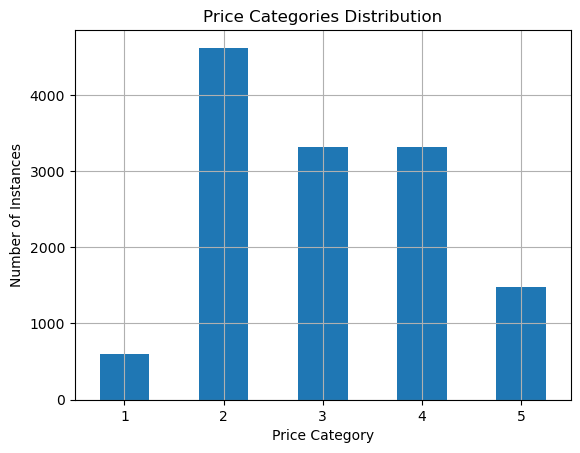

In [38]:
housing_data["price_cat"] = pd.cut(
    housing_data["price"],
    bins=[0, 30, 60, 90, 200,np.inf],
    labels=[1, 2, 3, 4, 5]
)
housing_data["price_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.title("Price Categories Distribution")
plt.xlabel("Price Category")
plt.ylabel("Number of Instances")
plt.show()

In [39]:
#Split the data based on price_cat column
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing_data, housing_data["price_cat"]):
    strat_train_set = housing_data.loc[train_index]
    strat_test_set = housing_data.loc[test_index]

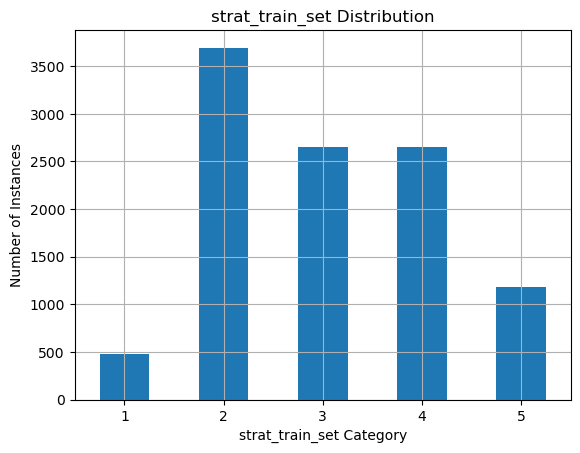

In [40]:
strat_train_set["price_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.title("strat_train_set Distribution")
plt.xlabel("strat_train_set Category")
plt.ylabel("Number of Instances")
plt.show()

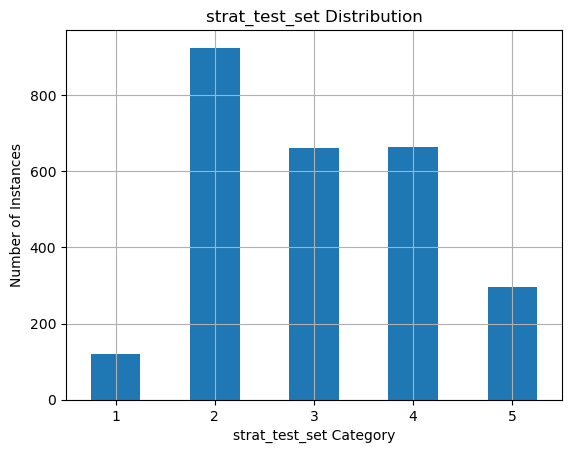

In [41]:
strat_test_set["price_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.title("strat_test_set Distribution")
plt.xlabel("strat_test_set Category")
plt.ylabel("Number of Instances")
plt.show()

<h1>On Training Data Set</h1>

<b>CAlculating and removing Outliers on the based on location.</b>
ex:<br>
In housing data, this situation is illogical:<br>
A 3 BHK house in the same location is cheaper per sqft than a 2 BHK house.

<b>Removing Outliers in total_sqrft</b><br>
Example interpretation<br>
0.054 actually means ₹5,400 per sqft<br>
0.082 means ₹8,200 per sqft<br>
120.0 means ₹12,000,000 per sqft (extreme outlier)

In [42]:
strat_train_set["price"]=strat_train_set["price"] * 100000
strat_train_set["price_per_sqft"] = (
    strat_train_set["price"] / strat_train_set["total_sqft"]
)

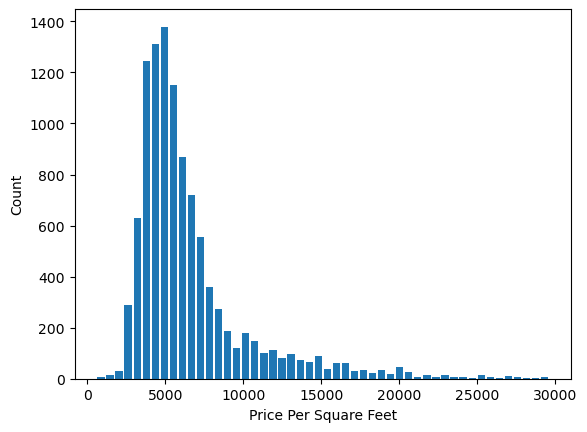

In [43]:
strat_train_set = strat_train_set[
    (strat_train_set.price_per_sqft > 500) &
    (strat_train_set.price_per_sqft < 30000)
]
plt.hist(strat_train_set.price_per_sqft, bins=50, rwidth=0.8)
plt.xlabel("Price Per Square Feet")
plt.ylabel("Count")
plt.show()

<b>Removing Outliers in BHK(Size)</b><br>

In [44]:
def remove_bhk_outliers(df):
    exclude_indices = np.array([])

    # Loop through each location
    for location, location_df in df.groupby('location'):
        bhk_stats = {}

        # Collect BHK statistics for this location
        for bhk, bhk_df in location_df.groupby('size'):
            bhk_stats[bhk] = {
                'mean': bhk_df.price_per_sqft.mean(),
                'std': bhk_df.price_per_sqft.std(),
                'count': bhk_df.shape[0]
            }

        # Compare higher BHK with lower BHK
        for bhk, bhk_df in location_df.groupby('size'):
            stats = bhk_stats.get(bhk - 1)

            if stats and stats['count'] > 5:
                exclude_indices = np.append(
                    exclude_indices,
                    bhk_df[bhk_df.price_per_sqft < stats['mean']].index.values
                )

    return df.drop(exclude_indices, axis='index')


# Apply the function
strat_train_set = remove_bhk_outliers(strat_train_set)
strat_train_set.shape

(8741, 7)

Text(0, 0.5, 'Count')

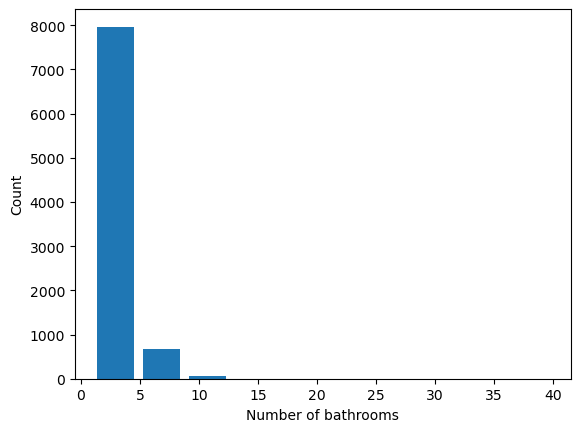

In [45]:
strat_train_set.bath.unique()
plt.hist(strat_train_set.bath,rwidth=0.8)
plt.xlabel("Number of bathrooms")
plt.ylabel("Count")

<h3>Selecting Only Numerical Columns and handling Misssing values</h3>

In [54]:
# Select only numerical columns
housing=strat_train_set.drop(["price","price_cat","price_per_sqft"],axis=True)
housing_labels=strat_train_set["price"].copy()

housing_num = housing.select_dtypes(include=[np.number])
# Create and apply median imputer
num_imputer = SimpleImputer(strategy="median")
housing_num_imputed = pd.DataFrame(
    num_imputer.fit_transform(housing_num),
    columns=housing_num.columns,
    index=housing_num.index
)
housing_num_imputed

,size,total_sqft,bath
6906,2.0,1200.0,2.0
1980,3.0,800.0,2.0
9917,2.0,1200.0,1.0
12531,3.0,1500.0,3.0
9006,3.0,1800.0,3.0
...,...,...,...
4665,1.0,662.0,1.0
7785,2.0,1194.0,2.0
3603,2.0,1157.0,2.0
7415,2.0,1200.0,2.0


Best practice for this dataset (recommended)<br>
<b>Reduce rare locations</b>

Group locations that appear less than a threshold into "other".
Why this step matters (interview-ready)

One-hot encoding high-cardinality features can cause dimensionality issues. Grouping rare categories improves model performance and generalization.

In [55]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

housing_cat = housing[["location"]]

housing_cat_encoded = pd.DataFrame(
    encoder.fit_transform(housing_cat),
    columns=encoder.get_feature_names_out(["location"]),
    index=housing_cat.index
)
housing_cat_encoded.columns = housing_cat_encoded.columns.str.replace(
    "location_", "", regex=False
)
print(type(housing_cat))        # should be pandas DataFrame
print(housing_cat.shape)        # (rows, 1)
housing_cat_encoded.head()

<class 'pandas.core.frame.DataFrame'>
(8741, 1)


,Banaswadi,Basavangudi,Bhoganhalli,Devarabeesana Halli,Devarachikkanahalli,Electronic City,Mysore Highway,Rachenahalli,Sector 1 HSR Layout,Thanisandra,...,mvj engineering college,pavitra paradise,"ravindra nagar, T.dasarahalli peenya",rr nagar,sankeswari,sapthagiri Layout,sarjapura main road,t.c palya,tc.palya,vinayakanagar
6906,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1980,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9917,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12531,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9006,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<b>Feature Scaling On Numerical Values</b>

In [56]:
std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num_imputed)
housing_num_std_scaled

array([[-0.55982127, -0.31483513, -0.4937683 ],
       [ 0.14875066, -0.68900413, -0.4937683 ],
       [-0.55982127, -0.31483513, -1.19249401],
       ...,
       [-0.55982127, -0.35505829, -0.4937683 ],
       [-0.55982127, -0.31483513, -0.4937683 ],
       [ 0.85732258,  1.39137552,  1.60240883]])

In [58]:
housing_num_std_scaled_df = pd.DataFrame(
    housing_num_std_scaled,
    columns=housing_num_imputed.columns,
    index=housing_num_imputed.index
)
housing_num_std_scaled_df

,size,total_sqft,bath
6906,-0.559821,-0.314835,-0.493768
1980,0.148751,-0.689004,-0.493768
9917,-0.559821,-0.314835,-1.192494
12531,0.148751,-0.034208,0.204957
9006,0.148751,0.246418,0.204957
...,...,...,...
4665,-1.268393,-0.818092,-1.192494
7785,-0.559821,-0.320448,-0.493768
3603,-0.559821,-0.355058,-0.493768
7415,-0.559821,-0.314835,-0.493768


<h3>Combine Them Both</h3>

In [59]:
housing_data_cleaned = pd.concat(
    [housing_num_std_scaled_df, housing_cat_encoded],
    axis=1
)
housing_data_cleaned

,size,total_sqft,bath,Banaswadi,Basavangudi,Bhoganhalli,Devarabeesana Halli,Devarachikkanahalli,Electronic City,Mysore Highway,...,mvj engineering college,pavitra paradise,"ravindra nagar, T.dasarahalli peenya",rr nagar,sankeswari,sapthagiri Layout,sarjapura main road,t.c palya,tc.palya,vinayakanagar
6906,-0.559821,-0.314835,-0.493768,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1980,0.148751,-0.689004,-0.493768,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9917,-0.559821,-0.314835,-1.192494,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12531,0.148751,-0.034208,0.204957,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9006,0.148751,0.246418,0.204957,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4665,-1.268393,-0.818092,-1.192494,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7785,-0.559821,-0.320448,-0.493768,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3603,-0.559821,-0.355058,-0.493768,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7415,-0.559821,-0.314835,-0.493768,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<b>Now Outliers has been removed, Handled Missing Values, Applied OneHotEncoder for categorical Values, Feature Scaling Done for Numerical Values</b><br>
Lets Train the model

In [65]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(housing_data_cleaned,housing_labels)

LinearRegression()

In [61]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(housing_data_cleaned,housing_labels)

DecisionTreeRegressor(random_state=42)

In [62]:
forest_reg = RandomForestRegressor(random_state=42)
forest_reg.fit(housing_data_cleaned,housing_labels)

RandomForestRegressor(random_state=42)

In [66]:
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import cross_val_score
lin_reg = -cross_val_score(
    lin_reg,
    housing_data_cleaned,
    housing_labels,
    scoring="neg_root_mean_squared_error",
    cv=10
)
 
# WARNING: Scikit-Learn’s scoring uses utility functions (higher is better), so RMSE is returned as negative.
# We use minus (-) to convert it back to positive RMSE.
print("Linear Regression CV RMSEs:", lin_reg)
print("\nCross-Validation Performance (linear Regression):")
print(pd.Series(lin_reg).describe())

Linear Regression CV RMSEs: [ 9162250.92456298  8849965.22927478 11502654.86395675  6643963.6236314
  9017102.65771486  8206873.87119885  7536113.07185517  6778562.73879554
  9086428.39808797  7853773.97924565]

Cross-Validation Performance (linear Regression):
count    1.000000e+01
mean     8.463769e+06
std      1.414841e+06
min      6.643964e+06
25%      7.615528e+06
50%      8.528420e+06
75%      9.069097e+06
max      1.150265e+07
dtype: float64


In [67]:
tree_rmses = -cross_val_score(
    tree_reg,
    housing_data_cleaned,
    housing_labels,
    scoring="neg_root_mean_squared_error",
    cv=10
)
 
# WARNING: Scikit-Learn’s scoring uses utility functions (higher is better), so RMSE is returned as negative.
# We use minus (-) to convert it back to positive RMSE.
print("Decision Tree CV RMSEs:", tree_rmses)
print("\nCross-Validation Performance (Decision Tree):")
print(pd.Series(tree_rmses).describe())

Decision Tree CV RMSEs: [11928970.43315019  9125770.41500333  8193279.25317624  6749295.38824107
  9466481.75423018 11746532.08497747  7175253.28763726  7794890.53059026
 10708254.79396065  8971004.43453442]

Cross-Validation Performance (Decision Tree):
count    1.000000e+01
mean     9.185973e+06
std      1.808231e+06
min      6.749295e+06
25%      7.894488e+06
50%      9.048387e+06
75%      1.039781e+07
max      1.192897e+07
dtype: float64


In [69]:
forest_reg = -cross_val_score(
    forest_reg,
    housing_data_cleaned,
    housing_labels,
    scoring="neg_root_mean_squared_error",
    cv=10
)
 
# WARNING: Scikit-Learn’s scoring uses utility functions (higher is better), so RMSE is returned as negative.
# We use minus (-) to convert it back to positive RMSE.
print("Random Forest CV RMSEs:", forest_reg)
print("\nCross-Validation Performance (Random Forest):")
print(pd.Series(forest_reg).describe())

Random Forest CV RMSEs: [8946860.48516813 7707709.62565309 7800786.74256422 6191824.12159996
 8478350.5362141  8955290.70261592 6336748.14053397 6125827.45507152
 8977389.71602597 7015959.2383042 ]

Cross-Validation Performance (Random Forest):
count    1.000000e+01
mean     7.653675e+06
std      1.175477e+06
min      6.125827e+06
25%      6.506551e+06
50%      7.754248e+06
75%      8.829733e+06
max      8.977390e+06
dtype: float64
